# Penalty-Weight Pareto Optimization

**Gate X - 45 trained pulses - seed 42 - `maxiter = 1500`**

The GRAPE cost function in `core/optimizer.optimize_multi_state_pulse` carries four
soft-penalty weights:

$$\mathcal{C}(u) \;=\; -\,\overline{F_{\mathrm{coh}}}
\;+\; \lambda_{\mathrm{disc}}\!\!\sum_{i\neq j}\!(F_i-F_j)^2
\;+\; \lambda_{\mathrm{deriv}} g_d(u)
\;+\; \lambda_{\mathrm{boundary}} g_b(u)
\;+\; \lambda_{\mathrm{amp}} g_a(u)$$

Every $\lambda$ term is a **regularizer**: it only ever *raises* the cost. So maximizing
the training objective alone drives all four to zero, which produces rough,
high-bandwidth pulses that overfit the training truncations `trunc_list = [22, 24, 26]`.

Choosing the weights is therefore a **multi-objective (Pareto)** problem:

> **Maximize the reported Pedersen fidelity on held-out cavity truncations, subject to
> RMS bandwidth $\leq$ 16 MHz.**

> **The reported metric is not the training metric.** $F_{\mathrm{coh}}$ is the
> optimizer's process objective; the headline number here is `pedersen_gate_fidelity`,
> computed from the full propagator via `main.report_pedersen_gate_fidelity` and
> evaluated at truncations the pulse never trained on.

---

## Executive summary

| | |
|---|---|
| **Recommended under 16 MHz** | $\lambda_{\mathrm{deriv}} = 10^{-6}$, other weights at incumbent |
| **Held-out Pedersen $F$** | **0.998716** (incumbent: 0.996243) |
| **RMS bandwidth** | 14.81 MHz (incumbent: 8.76 MHz) |
| **Trade** | $+2.5\times10^{-3}$ fidelity for $+6.1$ MHz bandwidth |

Three qualifications, each developed below and none of them cosmetic:

1. **$\lambda_{\mathrm{deriv}}$ is the only axis that matters.** It moves held-out $F$ by
   $1.2\times10^{-2}$. $\lambda_{\mathrm{boundary}}$ moves it by $\sim\!2\times10^{-3}$,
   $\lambda_{\mathrm{disc}}$ by $\sim\!10^{-3}$ and non-monotonically, and
   $\lambda_{\mathrm{amp}}$ by **exactly zero**.
2. **No run converged.** All 45 hit the `maxiter` cap. The fidelity *ranking* looks
   stable under continuation, but **bandwidth was still drifting** - which is the
   constrained axis, so the budget verdict is the soft part of this result.
3. **One seed.** Differences below the (unmeasured) across-seed spread are not rankings.

## 1. Setup

`RUN_SWEEP = False` loads the completed CSVs. Set it to `True` only to retrain - the
production run was ~10.7 h. The harness disk-caches every pulse, so a resumed run is cheap.

In [1]:
import os, sys, glob
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

REPO_ROOT = os.path.abspath(".")
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import visualization.penalty_viz as pv
from analysis.penalty_sweep import BASELINE, FIXED, PENALTY_NAMES, AXIS_NAMES

# NOTE: must come AFTER the imports above. `analysis.penalty_sweep` imports `main`,
# which calls matplotlib.use("Agg") at module scope -- that would silently override
# the inline backend and every figure below would render as a text repr.
%matplotlib inline
print("matplotlib backend:", matplotlib.get_backend())

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

# --- knobs -------------------------------------------------------------
RUN_SWEEP  = False   # True = retrain (~10.7 h); False = load the saved CSVs
GATE       = "X"
BW_BUDGET  = 16.0    # MHz, RMS bandwidth budget used for the recommendation
SEEDS      = [42]
MAXITER    = 1500
# -----------------------------------------------------------------------

print("incumbent recipe :", BASELINE)
print("sweep axes       :", AXIS_NAMES)
print("trained truncs   :", FIXED["trunc_list"])
print("bands (MHz)      :", FIXED["cav_band"], FIXED["tra_band"])
print("bandwidth budget :", BW_BUDGET, "MHz")

matplotlib backend: module://matplotlib_inline.backend_inline
incumbent recipe : {'deriv': 1e-05, 'boundary': 2e-05, 'amp': 8e-05, 'disc': 0.5}
sweep axes       : ('deriv', 'boundary', 'amp_max', 'disc')
trained truncs   : [22, 24, 26]
bands (MHz)      : (-27.0, 27.0) (-33.0, 33.0)
bandwidth budget : 16.0 MHz


## 2. Load the sweep

`load_sweep` prefers a full-run CSV and falls back to any bounded `*_demo` / `*_smoke`
artifact, so this notebook renders even mid-run.

In [2]:
def load_sweep(stem):
    "Prefer the full-run CSV; fall back to a bounded demo/smoke run."
    exact = f"tables/{stem}.csv"
    if os.path.exists(exact):
        print(f"loaded {exact}")
        return pd.read_csv(exact), exact
    alts = sorted(glob.glob(f"tables/{stem}_*.csv"))
    if alts:
        print(f"full run not found; falling back to {alts[-1]}")
        return pd.read_csv(alts[-1]), alts[-1]
    raise FileNotFoundError(f"no CSV for {stem}; run analysis/penalty_sweep.py first")


if RUN_SWEEP:
    from analysis.penalty_sweep import (
        build_ofat_configs, build_grid_configs, run_sweep, DEFAULT_EVAL_TRUNCS,
    )
    run_sweep(GATE, build_ofat_configs(), SEEDS, MAXITER, DEFAULT_EVAL_TRUNCS,
              f"tables/penalty_sweep_{GATE}_ofat.csv",
              f"results/penalty_sweep_{GATE}_ofat.json")
    run_sweep(GATE, build_grid_configs("deriv", "boundary"), SEEDS, MAXITER,
              DEFAULT_EVAL_TRUNCS,
              f"tables/penalty_sweep_{GATE}_grid_deriv_boundary.csv",
              f"results/penalty_sweep_{GATE}_grid_deriv_boundary.json")

df,   df_path   = load_sweep(f"penalty_sweep_{GATE}_ofat")
grid, grid_path = load_sweep(f"penalty_sweep_{GATE}_grid_deriv_boundary")
combined = pd.concat([df, grid], ignore_index=True)

print(f"\nOFAT : {len(df):3d} rows  |  grid : {len(grid):3d} rows  "
      f"|  combined : {len(combined)} trained pulses")
print("held-out truncations:", [n for n in sorted(set(range(16, 41, 2)))
                                if n not in FIXED["trunc_list"]])
df.head()

loaded tables/penalty_sweep_X_ofat.csv
loaded tables/penalty_sweep_X_grid_deriv_boundary.csv

OFAT :  20 rows  |  grid :  25 rows  |  combined : 45 trained pulses
held-out truncations: [16, 18, 20, 28, 30, 32, 34, 36, 38, 40]


,gate,label,swept,multiplier,is_baseline,seed,maxiter,lambda_deriv,lambda_boundary,lambda_amp,lambda_disc,amp_max,F_coh_train,iterations,converged,train_time_s,F_ped_heldout_mean,F_ped_heldout_min,F_ped_heldout_std,robustness_spread,F_ped_trained_mean,leakage_L1_mean,leakage_L1_max,overfit_gap,peak_amp,roughness,bandwidth_MHz,bandwidth_cav_MHz,bandwidth_tra_MHz,config_hash,reused_pulse,cached
0,X,deriv=0_boundary=2e-05_amp=8e-05_disc=0.5,deriv,0.0,False,42,1500,0.000000,0.00002,0.00008,0.5,40.0,0.999865,1500,False,830.342962,0.999343,0.995571,0.001280,0.004294,0.999858,0.000657,0.004427,0.000515,35.225146,3.162515,16.904023,9.857525,16.904023,651a62fe533443d4,False,False
1,X,deriv=1e-06_boundary=2e-05_amp=8e-05_disc=0.5,deriv,0.1,False,42,1500,0.000001,0.00002,0.00008,0.5,40.0,0.999245,1500,False,820.615855,0.998716,0.994835,0.001314,0.004410,0.999244,0.001283,0.005160,0.000528,20.801263,1.971562,14.809579,6.891229,14.809579,1579adc6fd43f79e,False,False
2,X,deriv=3e-06_boundary=2e-05_amp=8e-05_disc=0.5,deriv,0.3,False,42,1500,0.000003,0.00002,0.00008,0.5,40.0,0.998348,1500,False,819.194980,0.997871,0.994110,0.001261,0.004239,0.998345,0.002127,0.005885,0.000475,21.514974,1.741912,11.975877,6.463149,11.975877,5edaacb89c8ea4a1,False,False
3,X,deriv=1e-05_boundary=2e-05_amp=8e-05_disc=0.5,deriv,1.0,True,42,1500,0.000010,0.00002,0.00008,0.5,40.0,0.997632,1500,False,838.864162,0.996243,0.987193,0.003146,0.010436,0.997649,0.003752,0.012786,0.001407,18.908989,1.226538,8.755536,5.128992,8.755536,024ea7f9987444a0,False,False
4,X,deriv=3e-05_boundary=2e-05_amp=8e-05_disc=0.5,deriv,3.0,False,42,1500,0.000030,0.00002,0.00008,0.5,40.0,0.994637,1500,False,874.795184,0.994238,0.991511,0.000945,0.003130,0.994648,0.005757,0.008480,0.000410,24.083300,1.029562,5.914518,4.288989,5.914518,e8177dc9b2f41772,False,False


## 3. Data quality: **no run converged**

This is checked first because it conditions everything after it. L-BFGS-B stopped on the
iteration cap, not on a gradient or tolerance criterion, for every pulse in the study.

In [3]:
metric_cols = ["F_ped_heldout_mean", "bandwidth_MHz", "robustness_spread", "peak_amp"]
print("non-finite metric cells :", int(combined[metric_cols].isna().sum().sum()))
print("converged               :", combined["converged"].value_counts(dropna=False).to_dict())
capped = combined[combined["iterations"] >= combined["maxiter"]]
print(f"hit the iteration cap   : {len(capped)} / {len(combined)}")

non-finite metric cells : 0
converged               : {False: 45}
hit the iteration cap   : 45 / 45


45 / 45 capped. That is a **failed acceptance check**, not a footnote, so it needs to be
resolved rather than disclosed. The question splits in two, with different answers:

- Is the *fidelity ranking* trustworthy? Plausibly yes, if every config is equally
  under-trained.
- Is the *budget verdict* trustworthy? Only if bandwidth has stopped moving - because
  selection is "best fidelity **subject to** bandwidth $\leq$ 16 MHz."

`analysis/penalty_convergence_check.py` answers both empirically: it reloads a cached
pulse, continues it for 750 more iterations under the identical objective, and measures
how far the scored metrics move.

In [4]:
conv = pd.read_csv("tables/penalty_convergence_check.csv")
show = conv[["label", "extra_iters", "reconverged",
             "F_held_before", "F_held_after", "dF_held",
             "BW_before", "BW_after", "dBW"]].copy()
show["label"] = show["label"].str.replace("_boundary=2e-05_amp=8e-05_disc=0.5", "", regex=False)
show

,label,extra_iters,reconverged,F_held_before,F_held_after,dF_held,BW_before,BW_after,dBW
0,deriv=1e-05,750,False,0.996243,0.996819,0.000576,8.756,8.137,-0.619
1,deriv=1e-06,750,False,0.998716,0.998669,-0.000047,14.810,13.603,-1.207


**Neither reconverged even after 2250 total iterations**, and the two metrics behave
differently:

- **Fidelity is essentially plateaued.** It moved by $-4.7\times10^{-5}$ and
  $+5.8\times10^{-4}$ - small against the $2.5\times10^{-3}$ gap between these two
  configs. The ranking survives.
- **Bandwidth is *not* plateaued.** Both configs *lost* 0.6-1.2 MHz with more iterations.

The second point is the one that bites. The recommendation sits at 14.81 MHz and drifted
to 13.60 MHz; the single disqualified config ($\lambda_{\mathrm{deriv}} = 0$, 16.90 MHz)
sits only 0.9 MHz outside the budget and is drifting the same direction. **More
iterations could pull it under the line and change the recommendation.** So: trust the
ordering, treat the budget verdict as provisional.

## 4. One-factor-at-a-time response

Each column varies one axis with the others at the incumbent. Top row is the reported
held-out fidelity, bottom row the RMS bandwidth. They sit on **separate rows, not a shared
twin axis** - the scales are not commensurate and overlaying them would imply a trade-off
rate that does not exist. The dotted line marks the incumbent value.

Note the fourth axis is the amplitude **threshold** $\epsilon_{\max}$, not the weight
$\lambda_{\mathrm{amp}}$; Section 5 explains why.

Saved figures/penalty_ofat.png / .pdf


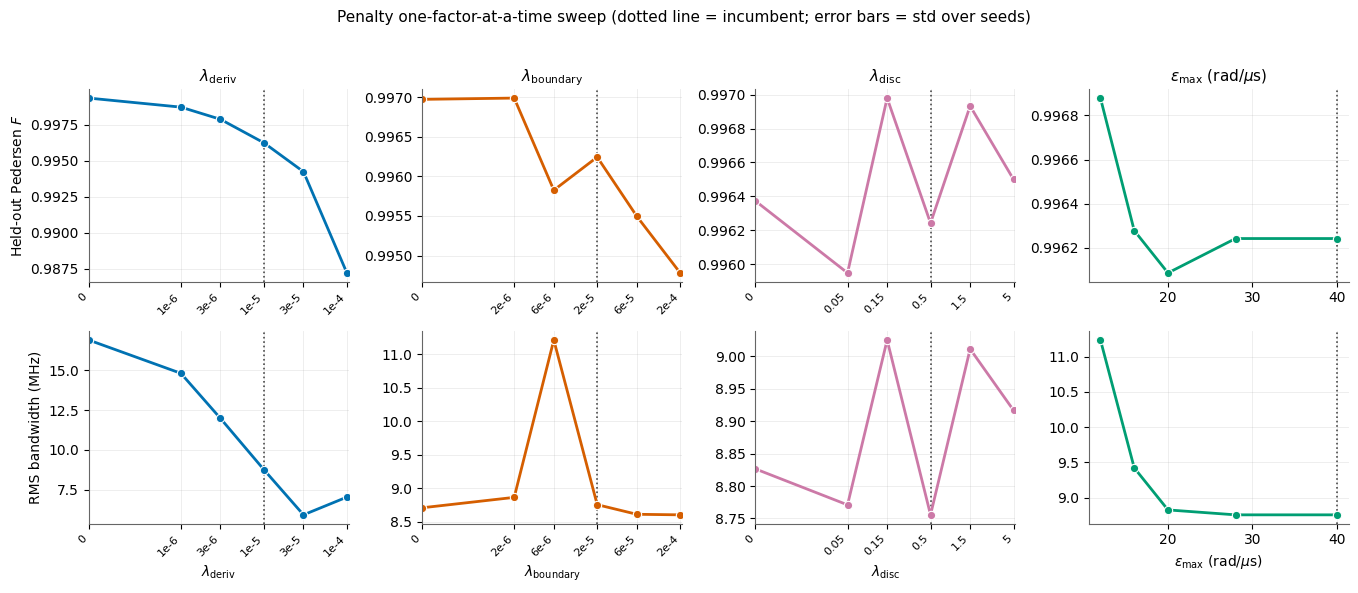

In [5]:
fig = pv.plot_ofat(df, save_path="figures/penalty_ofat")

> **Read the y-scales before the shapes.** Each panel is autoscaled independently, so the
> $\lambda_{\mathrm{disc}}$ zigzag *looks* as dramatic as the $\lambda_{\mathrm{deriv}}$
> trend while spanning about 10x less. The table below puts them on one scale.

## 5. Effect sizes: one axis does the work

Ranking the axes by how much they move each metric, end to end.

In [6]:
agg = pv.aggregate_seeds(df)
base = agg[agg["is_baseline"]].iloc[0]     # incumbent row, reused below

rows = []
for ax_name in AXIS_NAMES:
    sub = agg[agg["swept"] == ax_name]
    if sub.empty:
        continue
    col = pv.axis_column(ax_name)
    rows.append({
        "axis": ax_name,
        "swept from": f"{sub[col].min():.3g}",
        "to": f"{sub[col].max():.3g}",
        "range F_held": sub["F_ped_heldout_mean"].max() - sub["F_ped_heldout_mean"].min(),
        "range BW (MHz)": sub["bandwidth_MHz"].max() - sub["bandwidth_MHz"].min(),
        "range spread": sub["robustness_spread"].max() - sub["robustness_spread"].min(),
        "monotone in F": bool(
            np.all(np.diff(sub.sort_values(col)["F_ped_heldout_mean"]) <= 0)
            or np.all(np.diff(sub.sort_values(col)["F_ped_heldout_mean"]) >= 0)
        ),
    })
eff = pd.DataFrame(rows).set_index("axis").sort_values("range F_held", ascending=False)
eff.style.format({"range F_held": "{:.2e}", "range BW (MHz)": "{:.2f}",
                  "range spread": "{:.2e}"})

,swept from,to,range F_held,range BW (MHz),range spread,monotone in F
axis,,,,,,
deriv,0,0.0001,1.21e-02,10.99,9.30e-03,True
boundary,0,0.0002,2.21e-03,2.61,1.38e-02,False
disc,0,5,1.03e-03,0.25,7.44e-03,False
amp_max,12,28,7.91e-04,2.48,5.47e-03,False


$\lambda_{\mathrm{deriv}}$ dominates by an order of magnitude and is the only axis
monotone in fidelity. It is also the only one that moves bandwidth appreciably (11 MHz of
the 12 MHz total range). Everything else is second-order or noise.

### Why two axes were always going to be inert

Both of these are structural, and both were confirmed *at convergence* against the
canonical production pulse `pulses/u_X_main.npy` - not merely in the under-trained regime
above.

In [7]:
from core.grape_core import amplitude_penalty, make_hamiltonian, coherent_fidelity_multi_state
from analysis.penalty_sweep import GATE_FACTORIES

u_ref = np.load("pulses/u_X_main.npy")
print(f"canonical converged pulse, peak |u| = {np.abs(u_ref).max():.2f} rad/us")
for thr in (40.0, 15.0):
    g, gr = amplitude_penalty(u_ref, amp_max=thr)
    print(f"   amplitude_penalty(amp_max={thr:>4}) = {g:<9.3f} |grad| = {np.linalg.norm(gr):.3f}")

Fs = []
for nc in FIXED["trunc_list"]:
    H0, Hc = make_hamiltonian(3, nc)
    pairs = GATE_FACTORIES["X"](n_c=nc, n_t=3)
    F, _ = coherent_fidelity_multi_state(u_ref, H0, Hc, [a for a, b in pairs],
                                         [b for a, b in pairs], 0.002, want_grad=False)
    Fs.append(F)
Fs = np.array(Fs)
disc = sum((Fs[i] - Fs[j])**2 for i in range(len(Fs)) for j in range(len(Fs)) if i != j)
print(f"\nF_coh at n_c={FIXED['trunc_list']}: {np.round(Fs, 9)}")
print(f"disc_cost = sum_(i!=j) (F_i-F_j)^2 = {disc:.3e}")
print(f"   at lambda_disc = 5.0 this contributes {5.0*disc:.3e} against an O(1) fidelity term")

canonical converged pulse, peak |u| = 17.45 rad/us
   amplitude_penalty(amp_max=40.0) = 0.000     |grad| = 0.000
   amplitude_penalty(amp_max=15.0) = 73.617    |grad| = 17.160



F_coh at n_c=[22, 24, 26]: [0.99728657 0.99740428 0.99740967]
disc_cost = sum_(i!=j) (F_i-F_j)^2 = 5.808e-08
   at lambda_disc = 5.0 this contributes 2.904e-07 against an O(1) fidelity term


**$\lambda_{\mathrm{amp}}$ is exactly inert.** The soft cap is
$g_a(u) = \sum \max(0, |u| - \epsilon_{\max})^2$ with
$\epsilon_{\max} = 40$ rad/µs, but converged pulses peak near **17**. So
`amplitude_penalty` returns exactly `0.0` with an exactly zero gradient, and multiplying
zero by any weight changes nothing. The live knob is the *threshold*, which is why this
sweep varies $\epsilon_{\max}$ over 12-40 rad/µs in its place. (Even then it is a weak
axis: it moves held-out $F$ by $\sim\!7\times10^{-4}$, mostly by forcing *more* bandwidth
when the cap tightens - 8.8 MHz at $\epsilon_{\max}=40$ rising to 11.2 MHz at 12.)

**$\lambda_{\mathrm{disc}}$ is negligible by construction.** The three training
truncations already agree to $\sim\!10^{-4}$, so the discrepancy cost is
$\sim\!6\times10^{-8}$; at weight 5.0 that is $3\times10^{-7}$ against an $O(1)$ term -
seven orders down.

Yet the OFAT panel shows $\lambda_{\mathrm{disc}}$ moving held-out $F$ by $\sim\!10^{-3}$.
Both facts are true, and the reconciliation matters: a gradient contribution seven orders
down cannot *systematically* improve the pulse, but in a **non-convex, non-converged**
optimization it is easily enough to perturb the trajectory into a different local optimum.
The zigzag (non-monotone in both $F$ and bandwidth) is the signature of that, not of a
real effect. Distinguishing "disc helps" from "disc jiggles the trajectory" requires the
extra seeds this run does not have.

> A note on the original plan, which expected a wide held-out set to make `disc` bite: it
> cannot. Held-out truncations are a **scoring** set. The `disc` term is computed *inside
> training* over `trunc_list` only. Widening what you score on does not change the
> training gradient. Making `disc` matter requires more widely separated **training**
> truncations - which would change `FIXED` and break comparability with every pulse in
> `pulses/`.

Neither result is a bug: both terms are correctly implemented and would activate under
different settings. The conclusion is narrower and more useful - as configured, tuning
either weight is wasted compute, and the $\lambda_{\mathrm{amp}}$ term could be deleted
from the cost with no effect at all.

### An accidental replicate pair: the noise floor

The OFAT ladder builds its rungs as `BASELINE[name] * multiplier`, while the grid uses
literal values. In floating point those are not always the same number:
`2\times10^{-5} \times 3 = 6.000000000000001\times10^{-5}`, not `6\times10^{-5}`. The two
differ by one part in $10^{16}$ - physically nothing - but they hash differently, so the
harness trained them as separate configurations.

That accident is a gift: it gives **two independent runs of a physically identical recipe**
at the same seed and the same warm start. Whatever they disagree by is pure run-to-run
numerical chaos, and it calibrates every other difference in this notebook - without
spending a single extra optimization.

In [8]:
# Find labels trained under more than one distinct config_hash: same recipe to ~1e-16,
# independently optimized.
rep = (combined.groupby("label")["config_hash"].nunique()
       .loc[lambda s: s > 1].index.tolist())

rows = []
for lab in rep:
    sub = combined[combined["label"] == lab].drop_duplicates("config_hash")
    a, b = sub.iloc[0], sub.iloc[1]
    rows.append({
        "label": lab.replace("_amp=8e-05_disc=0.5", ""),
        "rel. weight diff": abs(a["lambda_boundary"] - b["lambda_boundary"]) /
                            max(a["lambda_boundary"], 1e-30)
                            + abs(a["lambda_deriv"] - b["lambda_deriv"]) /
                            max(a["lambda_deriv"], 1e-30),
        "|dF_held|": abs(a["F_ped_heldout_mean"] - b["F_ped_heldout_mean"]),
        "|dBW| (MHz)": abs(a["bandwidth_MHz"] - b["bandwidth_MHz"]),
        "|dspread|": abs(a["robustness_spread"] - b["robustness_spread"]),
    })
noise = pd.DataFrame(rows)
display(noise.style.format({"rel. weight diff": "{:.1e}", "|dF_held|": "{:.2e}",
                            "|dBW| (MHz)": "{:.3f}", "|dspread|": "{:.2e}"}))

floor_F  = noise["|dF_held|"].max()
floor_BW = noise["|dBW| (MHz)"].max()
print(f"\nempirical noise floor:  F_held ~ {floor_F:.1e}   bandwidth ~ {floor_BW:.2f} MHz")

,label,rel. weight diff,|dF_held|,|dBW| (MHz),|dspread|
0,deriv=1e-05_boundary=6e-05,1.1e-16,1.48e-04,0.018,1.53e-03
1,deriv=3e-05_boundary=2e-05,1.1e-16,3.53e-05,0.072,2.33e-04



empirical noise floor:  F_held ~ 1.5e-04   bandwidth ~ 0.07 MHz


In [9]:
# Calibrate the study's headline numbers against that floor.
disc_range = (agg[agg.swept == "disc"]["F_ped_heldout_mean"].max()
              - agg[agg.swept == "disc"]["F_ped_heldout_mean"].min())
rec_margin = 0.998716 - base["F_ped_heldout_mean"]

print(f"noise floor (F_held)                  : {floor_F:.2e}   (1x)")
print(f"lambda_disc full range                : {disc_range:.2e}   ({disc_range/floor_F:.0f}x floor)")
print(f"recommendation margin over incumbent  : {rec_margin:.2e}   ({rec_margin/floor_F:.0f}x floor)")
print(f"lambda_deriv full range               : {eff.loc['deriv','range F_held']:.2e}   "
      f"({eff.loc['deriv','range F_held']/floor_F:.0f}x floor)")

noise floor (F_held)                  : 1.48e-04   (1x)
lambda_disc full range                : 1.03e-03   (7x floor)
recommendation margin over incumbent  : 2.47e-03   (17x floor)
lambda_deriv full range               : 1.21e-02   (82x floor)


This settles how much weight each result can carry:

- The **recommendation's margin** over the incumbent is $\sim\!17\times$ the noise floor,
  and the $\lambda_{\mathrm{deriv}}$ effect is $\sim\!80\times$ it. Both are real.
- The **$\lambda_{\mathrm{disc}}$ range** is only $\sim\!7\times$ the floor *and*
  non-monotone in both fidelity and bandwidth. For a perturbation whose gradient
  contribution is seven orders below the fidelity term, "it moved the trajectory" explains
  this comfortably and "it improves the pulse" does not.
- **Any difference in these tables at the $10^{-4}$ level is not a difference.**

This is a floor, not the full seed-to-seed spread: it comes from a $10^{-16}$ perturbation,
whereas a genuine reseed changes the entire warm start. The real across-seed spread can
only be larger, which strengthens the conclusions above rather than weakening them.

## 6. Negative controls: is the trade-off real?

The premise of the exercise is that dropping a penalty **buys training fidelity and costs
bandwidth**. Each row is a $\lambda = 0$ config minus the incumbent. A positive
`dBandwidth` means the penalty was doing work.

In [10]:
base = agg[agg["is_baseline"]].iloc[0]
rows = []
for p in ("deriv", "boundary", "disc"):   # amp_max has no zero rung (it is a threshold)
    z = agg[(agg["swept"] == p) & (agg[f"lambda_{p}"] == 0.0)]
    if z.empty:
        continue
    z = z.iloc[0]
    rows.append({
        "penalty":      p,
        "dF_coh_train": z["F_coh_train"] - base["F_coh_train"],
        "dF_heldout":   z["F_ped_heldout_mean"] - base["F_ped_heldout_mean"],
        "dBandwidth":   z["bandwidth_MHz"] - base["bandwidth_MHz"],
        "dSpread":      z["robustness_spread"] - base["robustness_spread"],
        "dPeak":        z["peak_amp"] - base["peak_amp"],
    })
ctrl = pd.DataFrame(rows).set_index("penalty")
ctrl.round(5)

,dF_coh_train,dF_heldout,dBandwidth,dSpread,dPeak
penalty,,,,,
deriv,0.00223,0.00310,8.14849,-0.00614,16.31616
boundary,0.00028,0.00073,-0.04665,-0.00265,2.48615
disc,-0.00007,0.00013,0.07095,-0.00120,-0.04232


The $\lambda_{\mathrm{deriv}} = 0$ row is the clean demonstration: removing the smoothness
penalty buys $+2.2\times10^{-3}$ training fidelity and $+3.1\times10^{-3}$ held-out
fidelity, and pays **+8.1 MHz of bandwidth and +16.3 rad/µs of peak drive**. That pulse is
the best in the entire study on fidelity and is the *only* one disqualified by the budget.
The trade-off is real and it binds.

The other two rows move bandwidth by $\lesssim 0.1$ MHz - consistent with Section 5.

## 7. Focused 2-D grid: $\lambda_{\mathrm{deriv}} \times \lambda_{\mathrm{boundary}}$

The grid uses the two axes that measurably move the pulse. (A
$\lambda_{\mathrm{deriv}} \times \lambda_{\mathrm{disc}}$ grid was the original design;
by Section 5 it would have been constant along the `disc` axis.)

Single-hue sequential ramp - magnitude, not polarity - with bandwidth annotated in-cell so
the trade-off reads without a second color scale.

Saved figures/penalty_grid_heatmap.png / .pdf


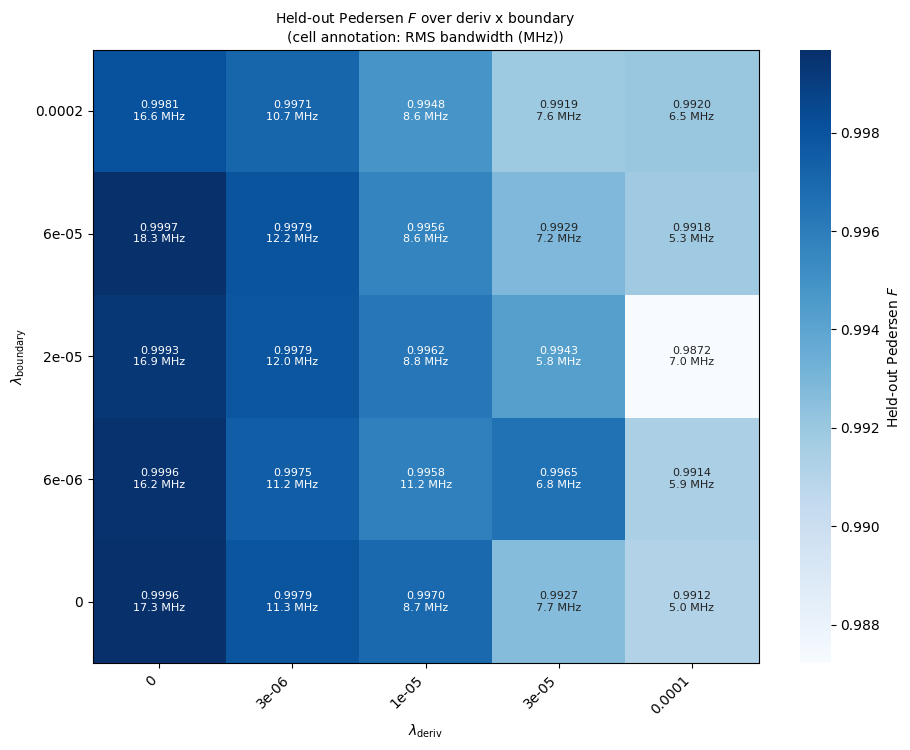

In [11]:
fig = pv.plot_grid_heatmap(grid, "deriv", "boundary",
                           save_path="figures/penalty_grid_heatmap")

In [12]:
# Is the grid actually 2-D, or is it 1-D in deriv?
gp = grid.pivot_table(index="lambda_boundary", columns="lambda_deriv",
                      values="F_ped_heldout_mean")
print("variation along deriv, at fixed boundary (per row):")
print((gp.max(axis=1) - gp.min(axis=1)).round(5).to_string())
print("\nvariation along boundary, at fixed deriv (per column):")
print((gp.max(axis=0) - gp.min(axis=0)).round(5).to_string())

variation along deriv, at fixed boundary (per row):
lambda_boundary
0.000000    0.00846
0.000006    0.00817
0.000020    0.01212
0.000060    0.00785
0.000200    0.00626

variation along boundary, at fixed deriv (per column):
lambda_deriv
0.000000    0.00157
0.000003    0.00081
0.000010    0.00219
0.000030    0.00466
0.000100    0.00481


Sweeping $\lambda_{\mathrm{deriv}}$ moves held-out $F$ by $\sim\!8\times10^{-3}$ at every
fixed $\lambda_{\mathrm{boundary}}$; sweeping $\lambda_{\mathrm{boundary}}$ moves it by
$\sim\!1\text{-}4\times10^{-3}$ at fixed $\lambda_{\mathrm{deriv}}$, non-monotonically.
**The grid is effectively one-dimensional.** There is no interaction worth exploiting -
the columns are near-copies of each other. That is a genuine (if deflationary) result:
the 25-cell grid confirms that tuning reduces to a single knob.

## 8. Pareto front and the budgeted recommendation

A configuration is non-dominated when no other is simultaneously narrower in bandwidth and
higher in held-out fidelity. The shaded region is **outside the budget**; the star is the
recommendation - highest held-out fidelity among configurations with
`bandwidth_MHz <= BW_BUDGET`; the open diamond is the incumbent.

The selection rule is fixed in advance so it cannot be retrofitted to the data: *among
budget-feasible configurations, take the highest mean held-out Pedersen fidelity; break
ties toward lower bandwidth.*

Saved figures/penalty_pareto.png / .pdf


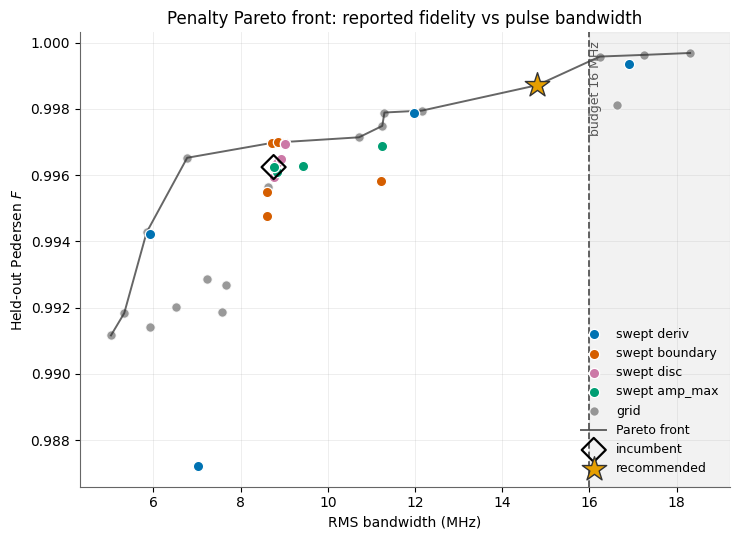

In [13]:
fig, rec = pv.plot_pareto(combined, save_path="figures/penalty_pareto",
                          max_bandwidth=BW_BUDGET)

In [14]:
agg_all = pv.aggregate_seeds(combined)
front = agg_all.iloc[pv.pareto_front(agg_all)]
print(f"Pareto front: {len(front)} of {len(agg_all)} configurations\n")
print(front[["label", "F_ped_heldout_mean", "bandwidth_MHz"]]
      .assign(within_budget=lambda d: d.bandwidth_MHz <= BW_BUDGET)
      .to_string(index=False))

infeasible = agg_all[agg_all["bandwidth_MHz"] > BW_BUDGET]
print(f"\ninfeasible (BW > {BW_BUDGET} MHz): {len(infeasible)} of {len(agg_all)}")
for _, r in infeasible.iterrows():
    print(f"   {r['label']}  BW={r['bandwidth_MHz']:.2f}  F={r['F_ped_heldout_mean']:.6f}")

Pareto front: 14 of 38 configurations

                                         label  F_ped_heldout_mean  bandwidth_MHz  within_budget
    deriv=0.0001_boundary=0_amp=8e-05_disc=0.5            0.991164       5.024563           True
deriv=0.0001_boundary=6e-05_amp=8e-05_disc=0.5            0.991835       5.328478           True
 deriv=3e-05_boundary=2e-05_amp=8e-05_disc=0.5            0.994273       5.842442           True
 deriv=3e-05_boundary=6e-06_amp=8e-05_disc=0.5            0.996523       6.772485           True
     deriv=1e-05_boundary=0_amp=8e-05_disc=0.5            0.996971       8.708888           True
 deriv=1e-05_boundary=2e-06_amp=8e-05_disc=0.5            0.996987       8.864739           True
deriv=3e-06_boundary=0.0002_amp=8e-05_disc=0.5            0.997141      10.714244           True
 deriv=3e-06_boundary=6e-06_amp=8e-05_disc=0.5            0.997485      11.248693           True
     deriv=3e-06_boundary=0_amp=8e-05_disc=0.5            0.997889      11.298417       

In [15]:
print(f"Recommended under {BW_BUDGET:g} MHz:\n  {rec['label']}\n")
print(f"  held-out Pedersen F : {rec['F']:.6f}")
print(f"  held-out F (min)    : {rec['F_ped_heldout_min']:.6f}")
print(f"  RMS bandwidth       : {rec['bandwidth']:.2f} MHz")
print(f"  robustness spread   : {rec['robustness_spread']:.3e}")
print(f"  peak amplitude      : {rec['peak_amp']:.1f} rad/us")
print("  penalties           :", {p: float(rec[f"lambda_{p}"]) for p in PENALTY_NAMES},
      f"amp_max={rec['amp_max']:.0f}")

Recommended under 16 MHz:
  deriv=1e-06_boundary=2e-05_amp=8e-05_disc=0.5

  held-out Pedersen F : 0.998716
  held-out F (min)    : 0.994835
  RMS bandwidth       : 14.81 MHz
  robustness spread   : 4.410e-03
  peak amplitude      : 20.8 rad/us
  penalties           : {'deriv': 1.0000000000000002e-06, 'boundary': 2e-05, 'amp': 8e-05, 'disc': 0.5} amp_max=40


### Recommendation vs the incumbent

In [16]:
comp = pd.DataFrame({"incumbent": base, "recommended": rec}).T
keep = [f"lambda_{p}" for p in PENALTY_NAMES] + [
    "amp_max", "F_ped_heldout_mean", "F_ped_heldout_min", "robustness_spread",
    "bandwidth_MHz", "peak_amp", "F_coh_train", "overfit_gap",
]
comp = comp[[c for c in keep if c in comp.columns]].astype(float)
comp.loc["delta"] = comp.loc["recommended"] - comp.loc["incumbent"]
comp.round(6)

,lambda_deriv,lambda_boundary,lambda_amp,lambda_disc,amp_max,F_ped_heldout_mean,F_ped_heldout_min,robustness_spread,bandwidth_MHz,peak_amp,F_coh_train,overfit_gap
incumbent,0.000010,0.00002,0.00008,0.5,40.0,0.996243,0.987193,0.010436,8.755536,18.908989,0.997632,0.001407
recommended,0.000001,0.00002,0.00008,0.5,40.0,0.998716,0.994835,0.004410,14.809579,20.801263,0.999245,0.000528
delta,-0.000009,0.00000,0.00000,0.0,0.0,0.002473,0.007641,-0.006027,6.054043,1.892274,0.001613,-0.000879


The recommendation is $\lambda_{\mathrm{deriv}} = 10^{-6}$ - a **10x reduction** from the
incumbent $10^{-5}$, with all other weights unchanged. It buys $+2.5\times10^{-3}$
held-out fidelity and $+7.6\times10^{-3}$ on the worst-case truncation, and it also
*halves* the robustness spread. The cost is $+6.1$ MHz of bandwidth and $+1.9$ rad/µs of
peak drive.

Whether that trade is worth taking is a hardware question, not an optimization one, which
is exactly why the budget enters as a constraint rather than as another term in
$\mathcal{C}(u)$. At a 16 MHz budget it clears comfortably; at a 12 MHz budget the
recommendation would instead be $\lambda_{\mathrm{deriv}} = 3\times10^{-6}$
($F = 0.997871$ at 11.98 MHz), and at 10 MHz it would fall back to roughly the incumbent.

In [17]:
# Budget sensitivity: how does the recommendation move with the constraint?
rows = []
for b in (8.0, 10.0, 12.0, 14.0, 16.0, 20.0):
    try:
        r = pv.recommend(agg_all, max_bandwidth=b)
        rows.append({"budget (MHz)": b, "recommended": r["label"],
                     "F_held": r["F"], "BW (MHz)": r["bandwidth"]})
    except ValueError:
        rows.append({"budget (MHz)": b, "recommended": "(none feasible)",
                     "F_held": np.nan, "BW (MHz)": np.nan})
sens = pd.DataFrame(rows)
sens["recommended"] = sens["recommended"].str.replace(
    "_boundary=2e-05_amp=8e-05_disc=0.5", "", regex=False)
sens.round(6)

,budget (MHz),recommended,F_held,BW (MHz)
0,8.0,deriv=3e-05_boundary=6e-06_amp=8e-05_disc=0.5,0.996523,6.772485
1,10.0,deriv=1e-05_boundary=2e-06_amp=8e-05_disc=0.5,0.996987,8.864739
2,12.0,deriv=3e-06_boundary=0_amp=8e-05_disc=0.5,0.997889,11.298417
3,14.0,deriv=3e-06_boundary=6e-05_amp=8e-05_disc=0.5,0.997947,12.159234
4,16.0,deriv=1e-06,0.998716,14.809579
5,20.0,deriv=0_boundary=6e-05_amp=8e-05_disc=0.5,0.999685,18.310801


## 9. Summary table

Written to `tables/penalty_sweep_summary.csv` and `.tex`; the LaTeX version is
`\input`-ed by `penalty_optimization_report.tex`.

In [18]:
summary = pv.summary_table(combined, out_csv="tables/penalty_sweep_summary.csv",
                           max_bandwidth=BW_BUDGET)
summary.head(12).round(6)

Saved tables/penalty_sweep_summary.csv
Saved tables/penalty_sweep_summary.tex


,label,swept,lambda_deriv,lambda_boundary,lambda_amp,lambda_disc,amp_max,F_ped_heldout_mean,F_ped_heldout_min,robustness_spread,bandwidth_MHz,peak_amp,roughness,F_coh_train,overfit_gap,within_budget,n_seeds
26,deriv=1e-06_boundary=2e-05_amp=8e-05_disc=0.5,deriv,0.000001,0.000020,0.00008,0.50,40.0,0.998716,0.994835,0.004410,14.809579,20.801263,1.971562,0.999245,0.000528,True,1
36,deriv=3e-06_boundary=6e-05_amp=8e-05_disc=0.5,derivxboundary,0.000003,0.000060,0.00008,0.50,40.0,0.997947,0.990997,0.007976,12.159234,21.974920,1.611529,0.998986,0.001019,True,1
34,deriv=3e-06_boundary=0_amp=8e-05_disc=0.5,derivxboundary,0.000003,0.000000,0.00008,0.50,40.0,0.997889,0.991334,0.007518,11.298417,23.425935,1.514961,0.998854,0.000982,True,1
35,deriv=3e-06_boundary=2e-05_amp=8e-05_disc=0.5,deriv,0.000003,0.000020,0.00008,0.50,40.0,0.997871,0.994110,0.004239,11.975877,21.514974,1.741912,0.998348,0.000475,True,1
37,deriv=3e-06_boundary=6e-06_amp=8e-05_disc=0.5,derivxboundary,0.000003,0.000006,0.00008,0.50,40.0,0.997485,0.987950,0.010991,11.248693,21.758020,1.578261,0.998945,0.001472,True,1
33,deriv=3e-06_boundary=0.0002_amp=8e-05_disc=0.5,derivxboundary,0.000003,0.000200,0.00008,0.50,40.0,0.997141,0.986067,0.012970,10.714244,18.026408,1.387347,0.999042,0.001854,True,1
22,deriv=1e-05_boundary=2e-06_amp=8e-05_disc=0.5,boundary,0.000010,0.000002,0.00008,0.50,40.0,0.996987,0.992055,0.005548,8.864739,19.382710,1.208639,0.997581,0.000591,True,1
14,deriv=1e-05_boundary=2e-05_amp=8e-05_disc=0.15,disc,0.000010,0.000020,0.00008,0.15,40.0,0.996980,0.993200,0.004313,9.025316,19.613699,1.247001,0.997511,0.000535,True,1
11,deriv=1e-05_boundary=0_amp=8e-05_disc=0.5,boundary,0.000010,0.000000,0.00008,0.50,40.0,0.996971,0.990135,0.007781,8.708888,21.395137,1.202454,0.997913,0.000938,True,1
20,deriv=1e-05_boundary=2e-05_amp=8e-05_disc=1.5,disc,0.000010,0.000020,0.00008,1.50,40.0,0.996933,0.992551,0.005049,9.011425,19.667022,1.249318,0.997599,0.000672,True,1


## 10. Caveats

- **No run converged (45/45 capped), and bandwidth had not stopped moving.** The fidelity
  ordering survived a 750-iteration continuation; the budget verdict did not fully. The
  disqualified $\lambda_{\mathrm{deriv}} = 0$ config sits 0.9 MHz outside the budget and
  was drifting toward it. **Re-running at higher `maxiter` is the outstanding item before
  the budget verdict should be treated as final.**
- **One seed.** L-BFGS-B here is non-convex and randomly warm-started. The accidental
  replicate pair in Section 5 puts a *floor* on run-to-run noise ($\sim\!10^{-4}$ in
  $F_{\mathrm{held}}$), which is enough to trust the $\lambda_{\mathrm{deriv}}$ effect and
  the recommendation, and enough to distrust the $\lambda_{\mathrm{disc}}$ zigzag. It is
  not a substitute for the true across-seed spread, which can only be larger. Seeds 7 and
  123 remain the outstanding measurement.
- **The OFAT and grid ladders do not share cache entries where they should.**
  `BASELINE[x] * 3` and the grid's literal `3e-5` differ in the 16th digit, so 2 configs
  were trained twice instead of being reused. Rounding the OFAT rungs to a fixed precision
  would fix it, at the cost of invalidating the affected cache entries (they would
  retrain). Left as-is here so the committed code reproduces the committed CSVs exactly.
- **Two of the four weights do nothing here.** $\lambda_{\mathrm{amp}}$ multiplies an
  identically-zero term; $\lambda_{\mathrm{disc}}$ contributes $\sim\!10^{-7}$ against an
  $O(1)$ objective. Both terms are correctly implemented - they simply never activate as
  configured.
- **The held-out set includes under-resolved truncations.** $n_c = 16, 18$ do not fully
  contain the $\alpha = \sqrt{3}$ cat ($\bar n = 3$), so they depress the held-out mean and
  dominate `robustness_spread` for *every* recipe. They are kept deliberately - a pulse
  that exploits the truncation wall fails there first - but the absolute value of
  `F_ped_heldout_mean` should not be quoted as "the gate fidelity". The per-truncation
  breakdown in the manifest JSON is the honest view.
- **`bandwidth_MHz` is an RMS spectral width, not an occupied-bandwidth spec.** It ranks
  candidates; it is not a hardware figure. The genuinely hard constraint is the band-limit
  projection inside the optimizer ($\pm 27 / \pm 33$ MHz), enforced by construction and
  never violated regardless of the weights.
- **Per-gate.** This is gate X. A recipe selected on X is a starting point for the others,
  not a validated setting for them.